In [1]:
%%time
import numpy as np
from utilities import fortran_restart_to_radstate, setup_infrastructure

from pySHiELD.radiation import RadiationState, RadiationConfig, RTE_RRTMGPDriver
from pySHiELD.physics_state import SurfaceState
from pySHiELD._config import PhysicsConfig
from pySHiELD.stencils.physics import calc_sigma

import matplotlib.pyplot as plt
import datetime
from pathlib import Path

2025-08-05 15:29:02|INFO|rank 0|ndsl.logging:Constant selected: ConstantVersions.UFS
CPU times: user 2.56 s, sys: 2.78 s, total: 5.34 s
Wall time: 3.12 s


In [2]:
dycore_data = Path("../../test_data/radtest/fv_core.res.tile1.nc")
phys_data = Path("../../test_data/radtest/phy_data.tile1.nc")
tracer_data = Path("../../test_data/radtest/fv_tracer.res.tile1.nc")

In [3]:
nx = 48
ny = 48
nz = 91
npx = nx + 1
npy = ny + 1
npz = nz + 1
levels = np.arange(npz)
layers = np.arange(nz)

date = datetime.datetime(2020, 1, 1, 12, tzinfo=datetime.timezone.utc)

In [4]:
quantity_factory, stencil_factory, grid_data = setup_infrastructure(nx, ny, nz, "eta91.nc")

In [5]:
# Quick fix:
grid_data.lon_agrid.field[:] = grid_data.lon.field[:-1,:-1]
grid_data.lat_agrid.field[:] = grid_data.lat.field[:-1,:-1]

In [6]:
conf = PhysicsConfig
radconf = RadiationConfig(
    deltsw = 3600.0,
    delt_rad = 3600.0,
    date=date,
    fhswr=1.0,
    fhlwr=1.0,
    isolar=10,
    icmphys=4,
    ico2flg=0,
    ioznflg=1,
    ictmflg=-1,
    ialbflg=-1,
    iemsflg=0,
    ldisable_radiation_quasi_sea_ice=False,
    solar_constant_file=Path("global_solarconstant_noaa_an.txt"),
    input_dir=Path("../../test_data/"),
    aerosol_file=Path("../../test_data/"),
    sollat=0.0,
    nstp=6,
    ivflip=1,
    lcnorm=False,
    lcrick=False,
    gfs_cloud_overlap=False,
)

In [7]:
sigma = calc_sigma(grid_data.ak.data, grid_data.bk.data, 0)
gridlon = grid_data.lon_agrid
gridlat = grid_data.lat_agrid

In [8]:
%%time
rad = RTE_RRTMGPDriver(config=radconf, gridlon=gridlon, gridlat=gridlat, sigma=sigma, quantity_factory=quantity_factory, stencil_factory=stencil_factory)

2025-08-05 15:29:03|INFO|rank 0|ndsl.logging: - Using new fixed solar constant = 1360.8
2025-08-05 15:29:03|INFO|rank 0|ndsl.logging:Using Constant Albedo 0.98
2025-08-05 15:29:03|INFO|rank 0|ndsl.logging:Enable radiation quasi-sea-ice
2025-08-05 15:29:03|INFO|rank 0|ndsl.logging:Using Fixed Surface Emissivity = 1.0 for lw


/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)


CPU times: user 2.23 s, sys: 341 ms, total: 2.57 s
Wall time: 2.64 s


In [9]:
state = RadiationState.init_zeros(quantity_factory, np)
sstate = SurfaceState.init_zeros(quantity_factory)

In [10]:
fortran_restart_to_radstate(dycore_datafile=dycore_data, phys_datafile=phys_data, tracer_datafile=tracer_data, ak=grid_data.ak, state=state)

In [35]:
%%time
rad.step_radiation(state, sstate, date)

CPU times: user 7.81 s, sys: 3.14 s, total: 10.9 s
Wall time: 12 s


In [100]:
xcol, ycol = np.unravel_index(np.argmax(state.qcld.field.sum(axis=2) + state.qliquid.field.sum(axis=2) + state.qice.field.sum(axis=2)), state.qliquid.field.sum(axis=2).shape)
# xcol, ycol = np.unravel_index(np.argmax(state.qliquid.field.sum(axis=2) + state.qice.field.sum(axis=2)), state.qliquid.field.sum(axis=2).shape)
print(xcol, ycol)
print(state.qliquid.field[xcol,ycol,:].sum())
print(gridlon.field[xcol,ycol]*180/3.141, gridlat.field[xcol, ycol]*180/3.141)
print(f"{date} UTC")

1 4
0.008401885749500942
-5.391642119789074 10.314445794379095
2020-01-01 12:00:00+00:00 UTC


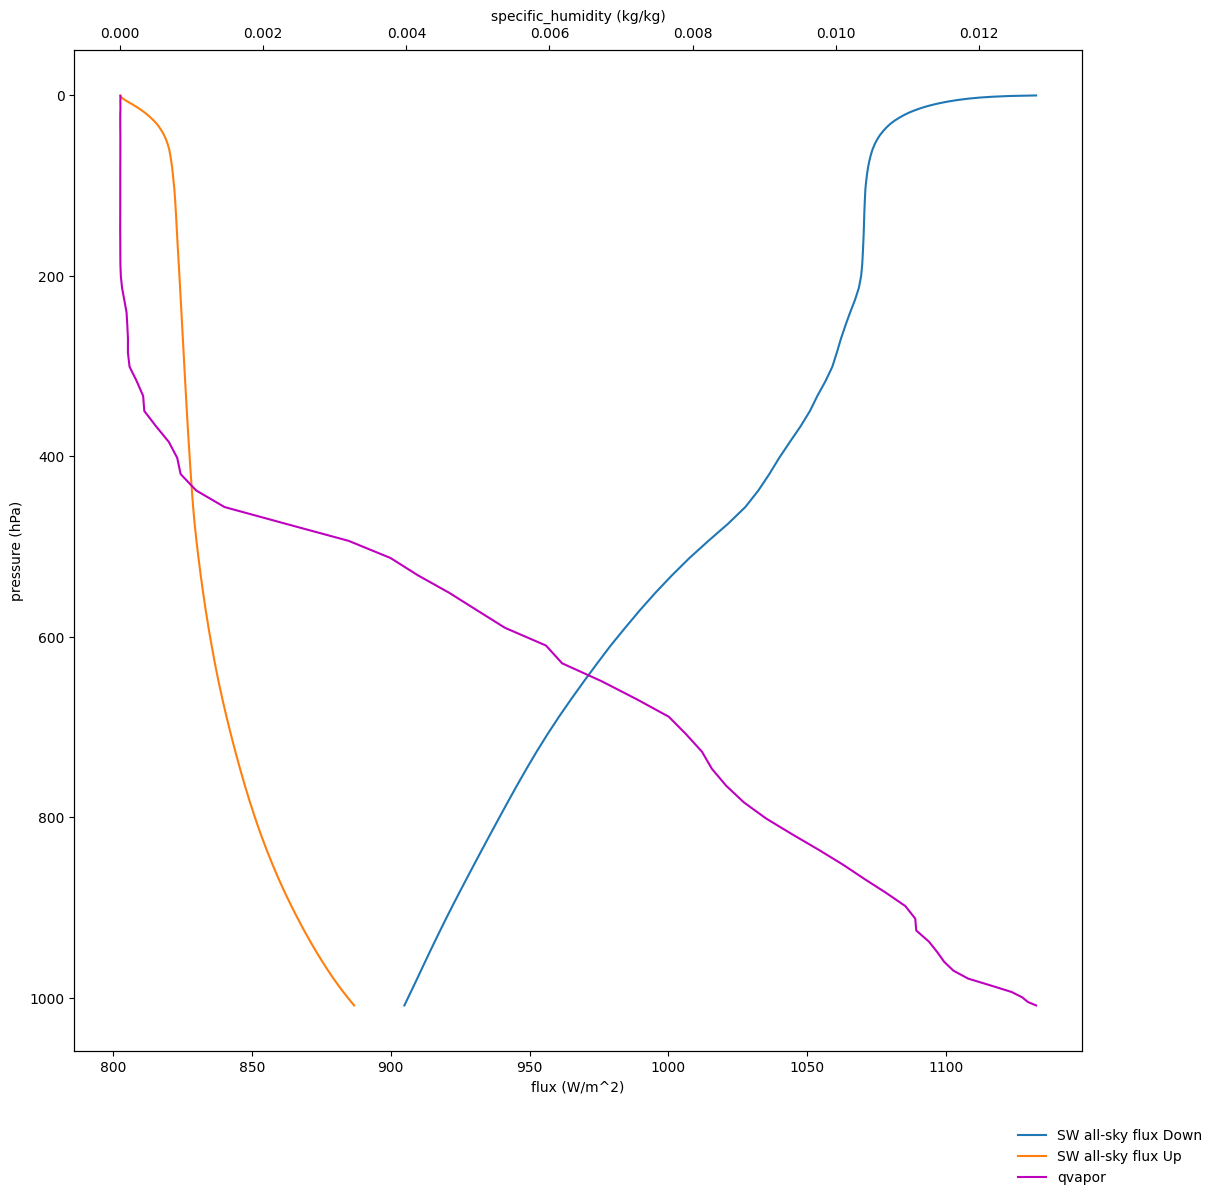

In [95]:
fig0 = plt.figure(0, figsize = (13,13))    #create  figure
f0ax1 = fig0.add_subplot(111) # define axes in which to plot
f0ax1.yaxis.set_inverted(True)
f0ax1.set_xlabel("flux (W/m^2)")
f0ax1.set_ylabel("pressure (hPa)")
f0ax1.plot(state.fswd.field[xcol, ycol,:], state.prsi.field[xcol, ycol, :]/100, label="SW all-sky flux Down")
f0ax1.plot(state.fswu.field[xcol, ycol,:], state.prsi.field[xcol, ycol, :]/100, label="SW all-sky flux Up")

f0ax2 = f0ax1.twiny()
f0ax2.set_xlabel("specific_humidity (kg/kg)")
f0ax2.plot(state.qvapor.field[xcol, ycol,:], state.prsi.field[xcol, ycol,:-1]/100, label="qvapor", color="m")

fig0.legend(frameon=False, loc=4)

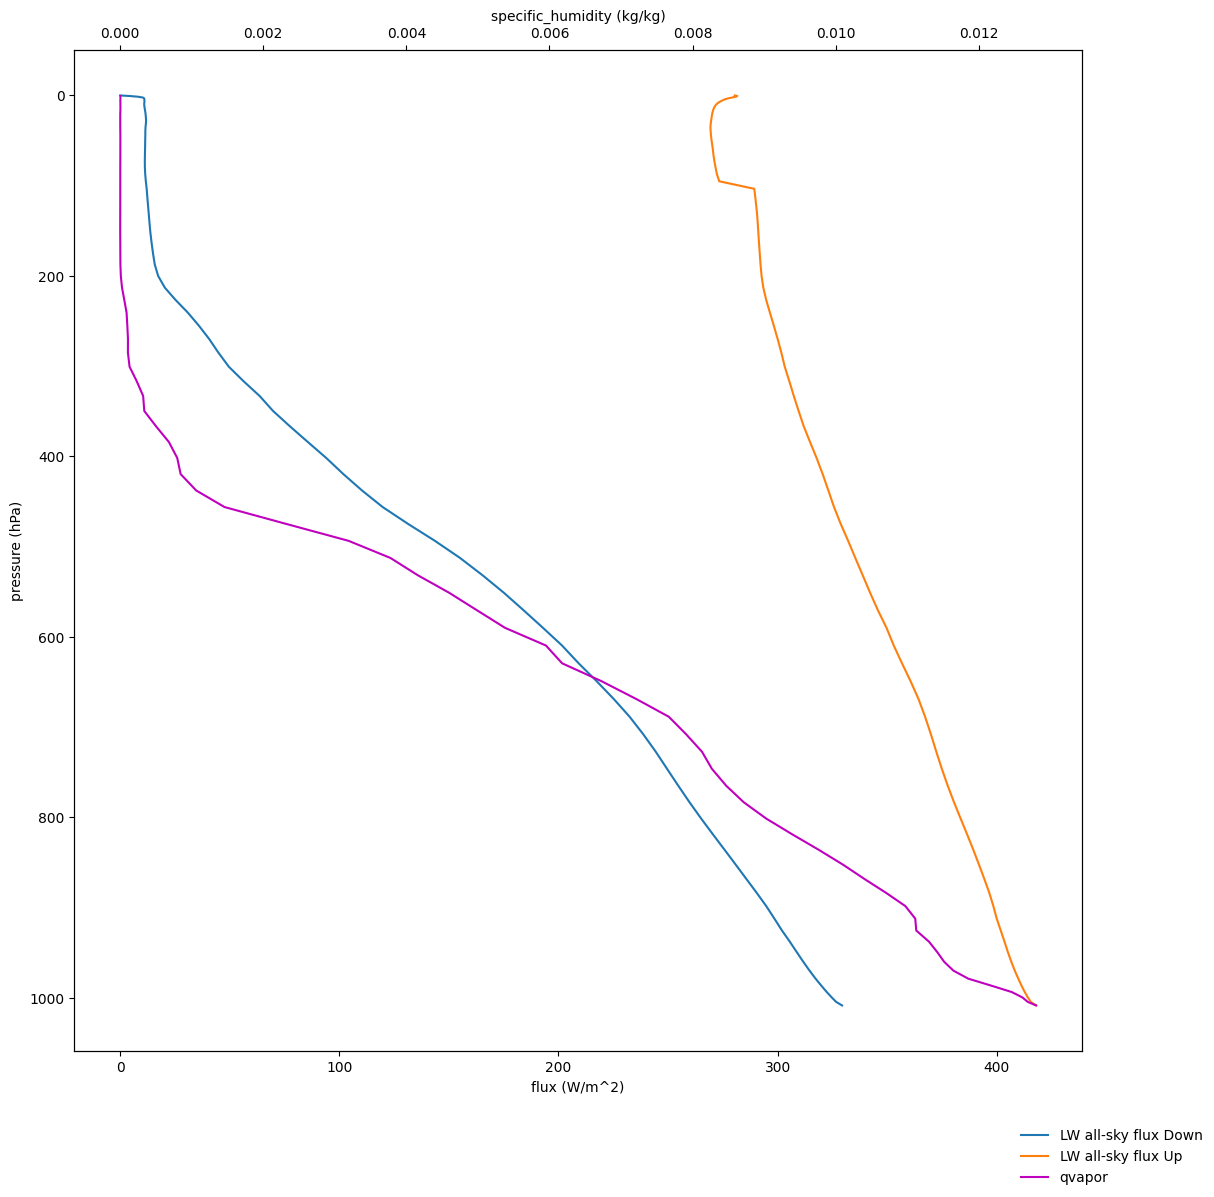

In [97]:
fig1 = plt.figure(1, figsize = (13,13))    #create  figure
f1ax1 = fig1.add_subplot(111) # define axes in which to plot
f1ax1.yaxis.set_inverted(True)
f1ax1.set_xlabel("flux (W/m^2)")
f1ax1.set_ylabel("pressure (hPa)")
f1ax1.plot(state.flwd.field[xcol, ycol,:], state.prsi.field[xcol, ycol, :]/100, label="LW all-sky flux Down")
f1ax1.plot(state.flwu.field[xcol, ycol,:], state.prsi.field[xcol, ycol, :]/100, label="LW all-sky flux Up")

f1ax2 = f1ax1.twiny()
f1ax2.set_xlabel("specific_humidity (kg/kg)")
f1ax2.plot(state.qvapor.field[xcol, ycol,:], state.prsi.field[xcol, ycol,:-1]/100, label="qvapor", color="m")

fig1.legend(frameon=False, loc=4)

In [30]:
newdate = date + datetime.timedelta(hours=11)
print(newdate)
rad.step_radiation(state, sstate, newdate)

2020-01-01 23:00:00+00:00


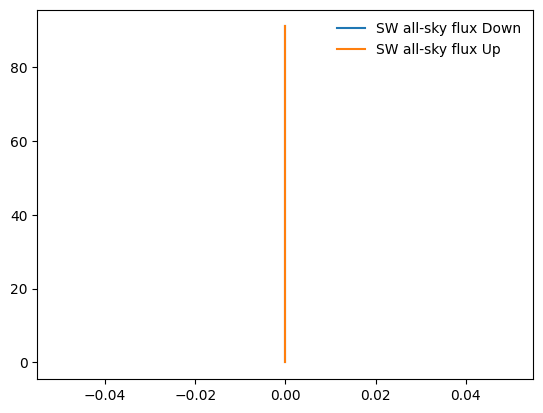

In [32]:
plt.plot(state.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(state.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.legend(frameon=False)

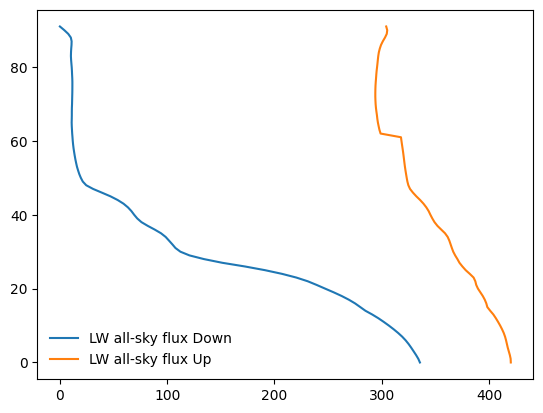

In [33]:
plt.plot(state.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(state.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)